# I. Analyzing Reproductive Health and Behavior Patterns Using NSFG 2022–2023

## 1. Dataset Acquisition

In [58]:
library(tidyverse)
library(survey)
library(srvyr)
library(MASS)
library(nnet)
library(patchwork)
library(svyVGAM)

In [6]:
df_fem <- read_csv("/content/NSFG_2022_2023_FemRespPUFData.csv", guess_max = Inf)

Rows: 5586 Columns: 1912
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr    (1): DEVICE_TYPE
dbl (1882): CaseID, RSCRAGE, RSCRNINF, RSCRHISP, RSCRRACE, FTFMODE, AGE_R, A...
lgl   (29): BIONUMHX_5, MARENDHX_5, ENDMARRX_Y_5, SEDBCLC4, CMCURRP2, CMCURR...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## 2. Variable Selection

- Count Variable
  - LIFPRTNR also known as the Lifetime number of opposite-sex sexual partners.
  - This is a non-negative integer that represents the frequency of a behavorial event over time.
  - It will support the Poisson Regression.

- Categorical (Nominal) Variable
  - CONSTAT1 also known as Current contraceptive status.
  - It has unordered categories and is used to analyze the differences in method choice across groups like marital status or race.
  - It will support Contingency Tables & Multinomial Logistic Regression.

- Ordered Categorical Variable
  - GENHEALT also known as Self-rated general health status.
  - The responses follow the natural ranking system of 1-5 (Where 1=Excellent and 5=Poor)
  - It is required to use Ordinal Logistic Regression

- Demographic Variables
  - AGER also known as Respondent's age at interview.
  - Age is a fundamental biological and social control variable, acting as a stable variable to determine factors affecting a group of people within certain age groups.
  - It will act as a Continuous Predictor.

  

---
- Demographic Variables
  - HISPRACE2 also known as Race and Hispanic Origin
  - This variable categorizes the respondents by specific minority groups ensuring the data is applicable to these groups
  - It will support Multiple Comparisons and ANOVA



---

- Demographic Variables
  - HIEDUC also known as Highest completed year of school or degree
  - Educations acts as a way to gauge the socio-economic status of a respondent while also accounting for their healthcare literacy and access to healthcare services
  - It will as a Socio-Economic Predictor

## 3. Data Cleaning

In [33]:
df_clean <- df_fem %>%
  rename_with(toupper) %>%
  filter(MARSTAT <= 3) %>%
  mutate(
    contraception_group = case_when(
      CONSTAT1 %in% c(1, 2) ~ "Sterilization",
      CONSTAT1 %in% c(5, 6, 7, 10, 11, 12) ~ "Hormonal/LARC",
      CONSTAT1 == 3 ~ "Barrier",
      CONSTAT1 >= 13 ~ "Other/None",
      TRUE ~ NA_character_
    ),
    marital_fact = factor(MARSTAT, labels = c("Married", "Cohabiting", "Neither")),
    health_ord = factor(GENHEALT, levels = c(1, 2, 3, 4, 5), ordered = TRUE),
    race_fact = factor(HISPRACE2, labels = c("Hispanic", "NH White", "NH Black", "Other"))
  ) %>%
  filter(!is.na(contraception_group), !is.na(GENHEALT), GENHEALT <= 5)

nsfg_design <- df_clean %>%
  as_survey_design(
    ids = VECL,
    strata = VEST,
    weights = WGT2022_2023,
    nest = TRUE
  )

## 4. Statistical Analyses

##### A. Poission Regression

In [66]:
mean_val <- svymean(~LIFPRTNR, nsfg_design, na.rm = TRUE)
var_val <- svyvar(~LIFPRTNR, nsfg_design, na.rm = TRUE)

print(mean_val)
print(var_val)

ratio <- as.numeric(var_val) / as.numeric(mean_val)
print(paste("Variance-to-Mean Ratio:", round(ratio, 2)))

          mean     SE
LIFPRTNR 5.969 0.1899
         variance     SE
LIFPRTNR   91.163 5.0394
[1] "Variance-to-Mean Ratio: 15.27"


In [59]:
pois_mod <- svyglm(LIFPRTNR ~ AGER + race_fact + HIEDUC, design = nsfg_design, family = poisson())

summary(pois_mod)


Call:
svyglm(formula = LIFPRTNR ~ AGER + race_fact + HIEDUC, design = nsfg_design, 
    family = poisson())

Survey design:
Called via srvyr

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)        0.240495   0.093840   2.563 0.013149 *  
AGER               0.037910   0.002593  14.622  < 2e-16 ***
race_factNH White  0.222246   0.072749   3.055 0.003468 ** 
race_factNH Black  0.333860   0.082102   4.066 0.000153 ***
race_factOther    -0.159648   0.140052  -1.140 0.259258    
HIEDUC             0.019480   0.012165   1.601 0.115020    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 14.00669)

Number of Fisher Scoring iterations: 6


Goodness-of-fit:

14.007, indicating extreme overdispersion

This can also be seen in the assumption check which has the variance so much higher thant the mean.

##### B. Contingency Tables

In [35]:
cont_table <- svytable(~MARSTAT + CONSTAT1, design = nsfg_design)

cont_table

       CONSTAT1
MARSTAT            1            2            3            5            6
      1  4569426.886  3649447.764   275838.726   163135.177  2557821.134
      2  1383406.959   278352.345   295392.037    83882.141  1080638.820
      3  2531954.674   262689.352  1278762.816   705932.739  4851958.143
       CONSTAT1
MARSTAT            7           10           11           12           13
      1    46744.291  2980505.462    35530.162  2859185.044        0.000
      2    17200.827   918512.117        0.000   724152.142     8701.934
      3   143863.934  2126509.766        0.000  1637538.925        0.000
       CONSTAT1
MARSTAT           19           20           21           22           30
      1   230941.456   640443.663  1198299.924    29422.709  1469763.070
      2        0.000   203132.987   605964.701        0.000   557092.923
      3    69005.160   336506.819   743527.106    36023.042   295284.362
       CONSTAT1
MARSTAT           31           32           33           34 

In [36]:
chisq_test <- svychisq(~marital_fact + contraception_group, design = nsfg_design)

chisq_test


	Pearson's X^2: Rao & Scott adjustment

data:  NextMethod()
F = 43.354, ndf = 5.4075, ddf = 324.4529, p-value < 2.2e-16


Intepretation:

The p-value is less than 0.05 indicating that the marital status of a woman is not independent of her contraceptive method and is instead a good predictor of it.

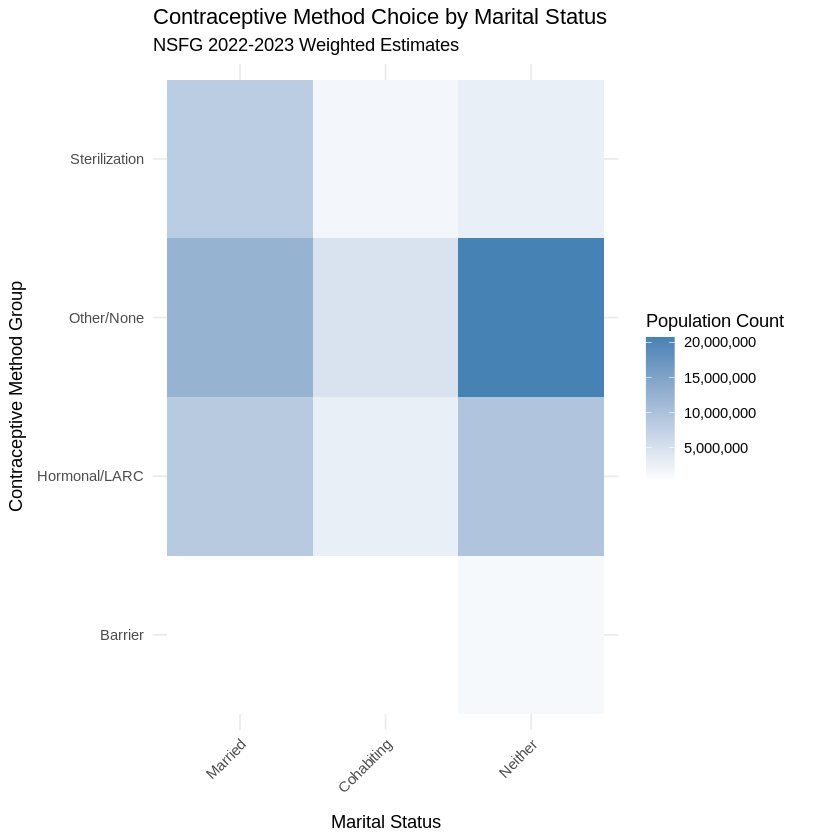

In [71]:
cont_table_labeled <- svytable(~marital_fact + contraception_group, design = nsfg_design)

as.data.frame(cont_table_labeled) %>%
    ggplot(aes(x = marital_fact, y = contraception_group, fill = Freq)) +
    geom_tile() +
    scale_fill_gradient(low = "white", high = "steelblue", labels = scales::comma) +
    labs(
        title = "Contraceptive Method Choice by Marital Status",
        subtitle = "NSFG 2022-2023 Weighted Estimates",
        x = "Marital Status",
        y = "Contraceptive Method Group",
        fill = "Population Count"
    ) +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))

##### C. Categorical Response Modeling

In [38]:
ord_mod <- svyolr(health_ord ~ AGER + HIEDUC + race_fact, design = nsfg_design)

summary(ord_mod)

Call:
svyolr(health_ord ~ AGER + HIEDUC + race_fact, design = nsfg_design)

Coefficients:
                        Value  Std. Error    t value
AGER               0.02913377 0.003723341  7.8246320
HIEDUC            -0.10610473 0.017872240 -5.9368457
race_factNH White -0.05490063 0.114764548 -0.4783763
race_factNH Black  0.05771716 0.127858561  0.4514141
race_factOther    -0.03248479 0.135804204 -0.2392031

Intercepts:
    Value   Std. Error t value
1|2 -1.0178  0.1499    -6.7884
2|3  0.6437  0.1461     4.4047
3|4  2.4161  0.1479    16.3336
4|5  4.3257  0.1745    24.7945

In [54]:
ord_summary <- cbind(
  "Log-Odds" = coef(ord_mod),
  "Odds Ratio" = exp(coef(ord_mod))
)

round(ord_summary, 3)

,Log-Odds,Odds Ratio
AGER,0.029,1.030
HIEDUC,-0.106,0.899
race_factNH White,-0.055,0.947
race_factNH Black,0.058,1.059
race_factOther,-0.032,0.968
1|2,-1.018,0.361
2|3,0.644,1.904
3|4,2.416,11.203
4|5,4.326,75.618


In [46]:
nom_mod <- svyVGAM::svy_vglm(contraception_group ~ AGER + HIEDUC + race_fact,
                   design = nsfg_design,
                   family = multinomial(refLevel = "Other/None"))

summary(nom_mod)

svy_vglm.survey.design(contraception_group ~ AGER + HIEDUC + 
    race_fact, design = nsfg_design, family = multinomial(refLevel = "Other/None"))
Stratified 1 - level Cluster Sampling design (with replacement)
With (80) clusters.
Called via srvyr
Sampling variables:
  - ids: VECL 
  - strata: VEST 
  - weights: WGT2022_2023 
Data variables: 
  - CASEID (dbl), RSCRAGE (dbl), RSCRNINF (dbl), RSCRHISP (dbl), RSCRRACE
    (dbl), FTFMODE (dbl), DEVICE_TYPE (chr), AGE_R (dbl), AGESCRN (dbl), HISP
    (dbl), HISPGRP (dbl), ROSCNT (dbl), NUMCHILD (dbl), HHKIDS18 (dbl),
    NONBIOKIDS (dbl), MARSTAT (dbl), LMARSTAT (dbl), RMARIT (dbl), EVRMARRY
    (dbl), SSMARCOH (dbl), MANREL (dbl), EARNHS_Y (dbl), MYSCHOL_Y (dbl),
    EARNBA_Y (dbl), WTHPARNW (dbl), ONOWN (dbl), ONOWN18 (dbl), INTACT (dbl),
    PARMARR (dbl), INTACT18 (dbl), LVSIT14F (dbl), LVSIT14M (dbl), WOMRASDU
    (dbl), MOMWORKD (dbl), MANRASDU (dbl), FOSTEREV (dbl), MNYFSTER (dbl),
    DURFSTER (dbl), AGEFSTER (dbl), MARSTATB (dbl), E

In [55]:
nommod_summary <- cbind(
  "Log-Odds" = coef(nom_mod),
  "Odds Ratio" = exp(coef(nom_mod))
)

round(nommod_summary, 3)

,Log-Odds,Odds Ratio
(Intercept):1,-1.567,0.209
(Intercept):2,-1.208,0.299
(Intercept):3,-5.969,0.003
AGER:1,-0.052,0.950
AGER:2,-0.009,0.991
AGER:3,0.144,1.155
HIEDUC:1,0.062,1.064
HIEDUC:2,0.156,1.169
HIEDUC:3,-0.086,0.917
race_factNH White:1,-0.600,0.549


Intepretation:

Looking at the Odd ratios for the Ordinal Logistic Regression the AGER variable is at 1.030, showing that for every year increase in age, the chances of being in a poorer health category increases.

For the HIEDUC the Odd ratio is at 0.899, showing that an increase in higher education, the odds of reporting poorer health decreases.

The t-values show that the AGER and the HIEDUC are from zero indicating that these are predictors that are significant contributors to the model's power. The same can be said of the Intercept Thresholds where their t-values show that they are statistically significant.

For the Multinomial Logistic Regression, the Odd ratios for AGER shows it is a strong pedictor of sterilization with the log-odds of sterilization of Group 1 relative to None/Other decreases as age increases, but the strong positive coefficient for Group 3 suggest that younger groups more on Other/None than barriers compared to the reference

With the HIEDUC the Odd ratio shows that a higher education increases the odds of using Hormonal/LARC methods compared to the Other/None group.

The z-values show that AGER and HIEDUC are essentially 0, meaning that they are improving the fit of the model compared to without them.

##### D. Exploratory Data Analysis & Multiple Comparisons

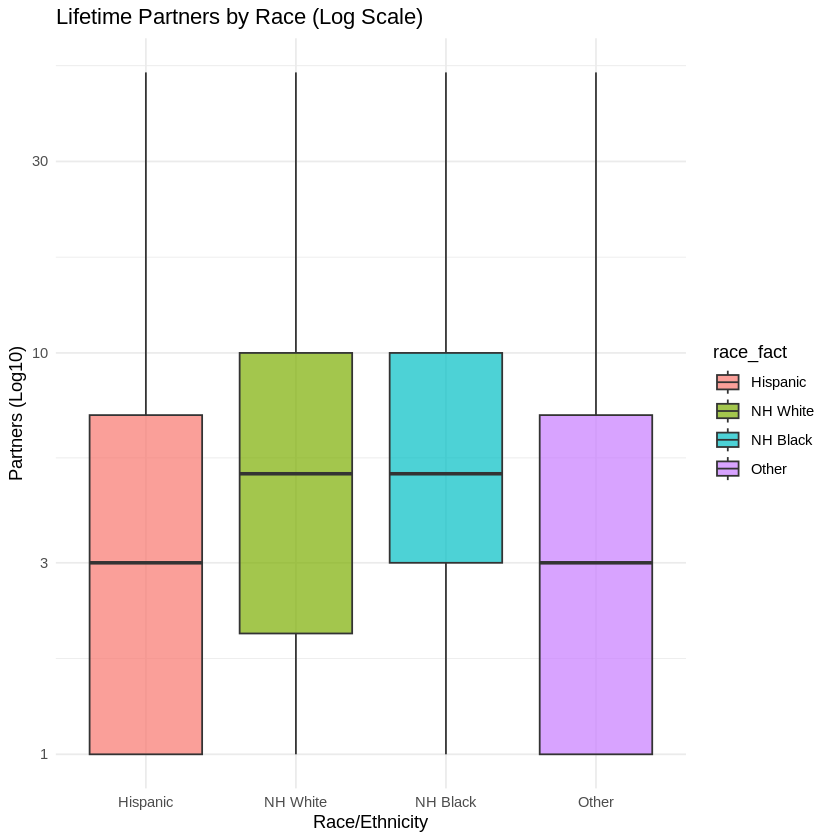

In [70]:
df_clean %>%
  filter(LIFPRTNR > 0) %>%
  ggplot(aes(x = race_fact, y = LIFPRTNR, fill = race_fact)) +
  geom_boxplot(alpha = 0.7) +
  scale_y_log10() +
  labs(title = "Lifetime Partners by Race (Log Scale)",
       x = "Race/Ethnicity", y = "Partners (Log10)") +
  theme_minimal()

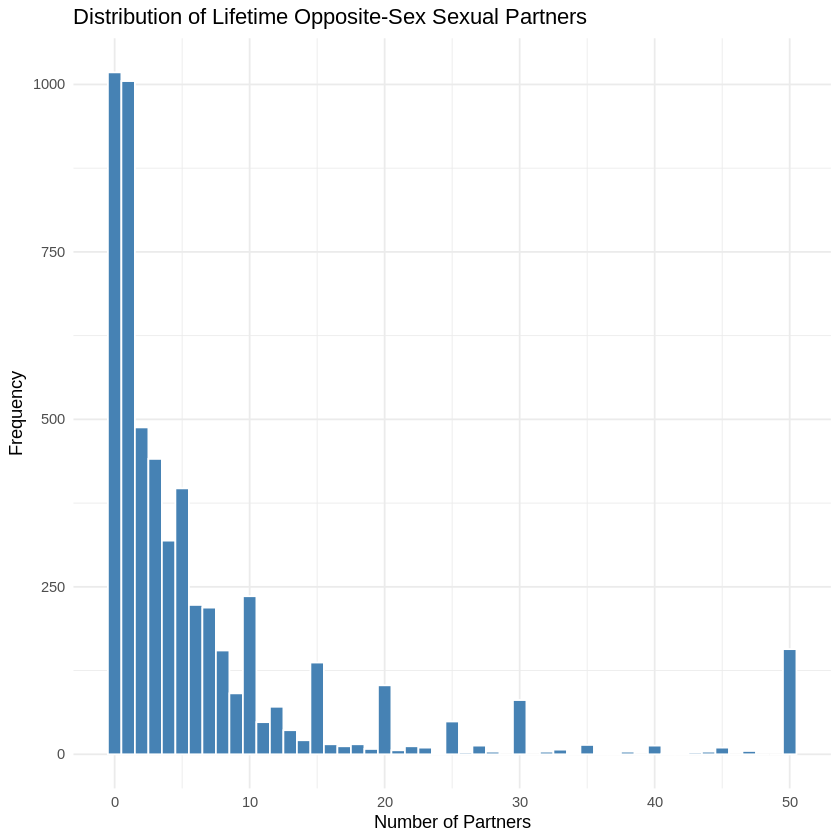

In [68]:
df_clean %>%
  ggplot(aes(x = LIFPRTNR)) +
  geom_histogram(binwidth = 1, fill = "steelblue", color = "white") +
  labs(title = "Distribution of Lifetime Opposite-Sex Sexual Partners",
       x = "Number of Partners",
       y = "Frequency") +
  theme_minimal()

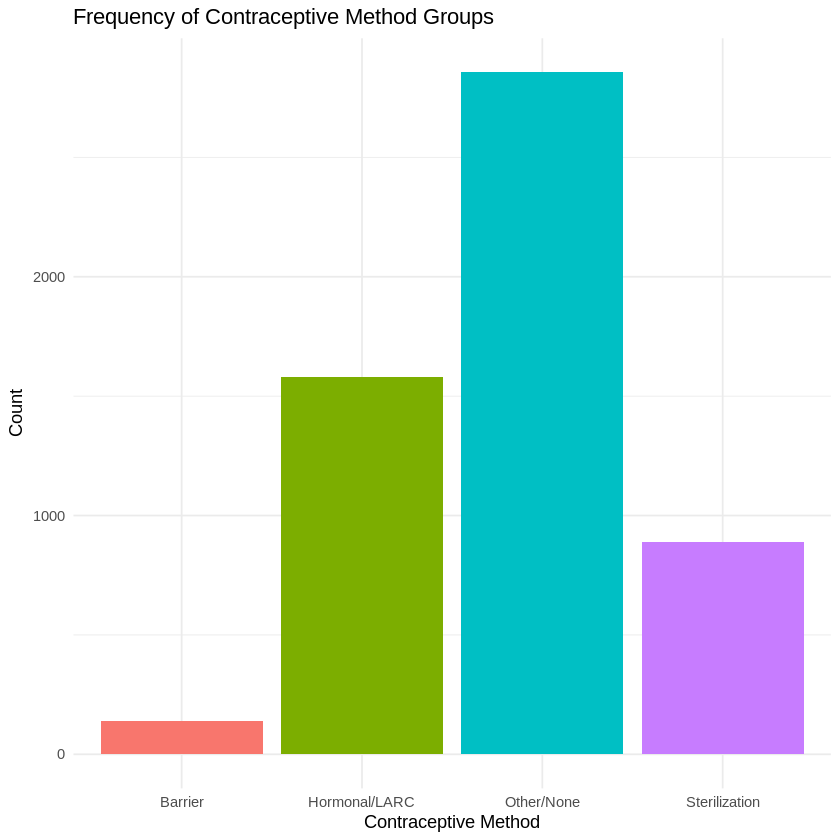

In [69]:
df_clean %>%
  ggplot(aes(x = contraception_group, fill = contraception_group)) +
  geom_bar() +
  labs(title = "Frequency of Contraceptive Method Groups",
       x = "Contraceptive Method",
       y = "Count") +
  theme_minimal() +
  theme(legend.position = "none")

In [52]:
pairwise.t.test(df_clean$LIFPRTNR, df_clean$race_fact, p.adjust.method = "bonferroni")


	Pairwise comparisons using t tests with pooled SD 

data:  df_clean$LIFPRTNR and df_clean$race_fact 

         Hispanic NH White NH Black
NH White 5.3e-10  -        -       
NH Black 2.3e-05  1.0000   -       
Other    1.0000   7.1e-06  0.0013  

P value adjustment method: bonferroni 

Discussion:

When doing multiple statistical tests the chances of runnning into a Type-1 error increases (also known as a "false positive").

This can be alleviated using the bonferroni method which reduces this risk and makes it harder to achieve. Allowing for the tests to remain reliable and not due to any luck or unluck.